# NLMEM Preconditionner simulation study
Le document suivant résume l'étude de simulation pour la modèle à effets-mixtes non linéaire

In [190]:
import jax.numpy as jnp
import jax.random as jrd

import parametrization_cookbook.jax as pc

import sdg4varselect as sdg
import sdg4varselect.new_plot as sdgplt

## Model sepecification
Le modèle que l'on souhaite étudier est le suivant : 

$$Y_{i,j} = \frac{\varphi_{1,i}}{1+ \exp\left(\frac{-(t_{i,j}- \xi_i}\tau\right)}$$

Où $\xi_i = \beta^T X + \varphi_{2,i}$ et $\varphi  \sim \mathcal N(\mu, \Gamma^2)$

Le code ci-dessous le définie pour python.

In [191]:
import functools
from jax import jit

from sdg4varselect.models import (
    AbstractMixedEffectsModel as AbstractMEM,
    AbstractHDModel,
    cov_simulation,
)


class LogisticMixedEffectsModel(AbstractMEM, AbstractHDModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractHDModel.__init__(self, P=P)
        AbstractMEM.__init__(self, N=N, J=J, me_name=["phi1", "phi2"], **kwargs)

    @property
    def name(self):
        return f"LogisticMEM_N{self.N}_J{self.J}_P{self.P}"

    def init_parametrization(self):
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.RealPositive(scale=100),
                mu2=pc.RealPositive(scale=2000),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(100, 2000)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = supremum
        phi2 = midpoint
        tau = growth rate
        """
        ksi = cov @ params.beta + phi2

        out = phi1[:, None] / (1 + jnp.exp(-(times - ksi[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    def sample(self, params_star, prngkey, **kwargs):
        """Sample one data set for the model"""

        (prngkey_time, prngkey_mem, prngkey_cov) = jrd.split(prngkey, num=3)

        # === nlmem_simulation() === #
        time = jnp.linspace(100, 1800, self.J)
        time = jnp.tile(time, (self.N, 1))
        time += 10 * jrd.uniform(prngkey_time, minval=-2, maxval=2, shape=time.shape)

        cov = cov_simulation(prngkey_cov, cov_min=-1, cov_max=1, shape=(self.N, self.P))

        obs, sim = AbstractMEM.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim

Les temps d'observation sont dans $[100,1800]$ échantillionné de manière régulière afin d'obtenir $J$ observation par individu.

Les covariables sont tirées selon une uniforme entre $[-1,1]$ puis recentré (selon les colonnes).

La fonction "init" ci dessus définie la parametrization utilisé pour $\theta$. Elle nomme également les composante de $\theta$. $cov_latent$, la matrice de variance-covariance des variables latentes, est définie comme une matrice diagonale positive de dimension 2 : $\theta$ aura alors 4 composantes nommé respectivement cov_latent1, cov_latent2, cov_latent3, cov_latent4. Evidement cov_latent2 = cov_latent3 = 0 et cov_latent1 et cov_latent2 sont les variances des $\gamma_1^2$ et  $\gamma_2^2$

## Theta star 

Ci dessous on définie $\theta^*$ la valeur utilisé lors des simulations des data-set, ie la valeur que l'on souhaite retrouver en fin d'estimation. On se place dans tout ce qui suis dans le cas où $N = 200,J=15$ et $ P = 500$

In [192]:
myModel = LogisticMixedEffectsModel(N=200, J=15, P=500)
# def get_star_p(cov, beta): return myModel.hstack_params(p_star)
p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([50, 2000])),
    tau=150,
    var_residual=30,
    beta=jnp.concatenate(
        [jnp.array([300, 100, 50]), jnp.zeros(shape=(myModel.P - 3,))]
    ),
)

p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([50, 1000])),
    tau=150,
    var_residual=30,
    beta=jnp.concatenate(
        [jnp.array([300, 100, -200]), jnp.zeros(shape=(myModel.P - 3,))]
    ),
)

# Results loading

On charge ici les resultats de simulations pour différent scénarios

In [193]:
import pandas as pd
from sdg4varselect.outputs import TestResults, MultiRunRes

m = LogisticMixedEffectsModel
# config = [
#     {"name": "Fisher", "seed_name": "Snotf(1, 10)", "N": 200, "P": 500},
#     {"name": "adagrad", "seed_name": "S(1, 10)", "N": 200, "P": 500},
#     {"name": "adagrad", "seed_name": "S(1, 2)", "N": 200, "P": 500},
#     {"name": "adagrad2", "seed_name": "S(1, 10)", "N": 200, "P": 500},
# ]
# config = [
#     {"name": "Fisher", "seed_name": "S(1, 10)", "N": 200, "P": 500},
#     {"name": "fisheradagrad", "seed_name": "S(1, 11)", "N": 200, "P": 500},
# ]
config = [
    # {"name": "Fisher", "seed_name": "200_S(1, 9)", "N": 200, "P": 10},
    {"name": "Fisher", "seed_name": "1000_S(1, 9)", "N": 200, "P": 10},
    # {"name": "Fisher", "seed_name": "2000_S(1, 9)", "N": 200, "P": 10},
]
# config = [
#     # {"name": "Fisher", "seed_name": "100_80_50_S(1, 10)", "N": 200, "P": 500},
#     # {"name": "Fisher", "seed_name": "S(1, 10)", "N": 200, "P": 10},
# ]


from sdg4varselect._regularization_function import eBIC, BIC

runres = []
for c in config:
    myModel = m(N=c["N"], J=15, P=c["P"])
    multires = MultiRunRes.load(
        myModel,
        "files",
        filename_add_on=f"{c['seed_name']}_{c['name']}",
    )

    print(multires[0].ebic)

    if True or multires[0].ebic == jnp.nan:  # .any():
        for i in range(len(multires)):
            print(i)
            reg = multires[i]  # .standardize()

            ebic = []
            bic = []
            for step in range(reg.last_theta.shape[0]):
                x = jnp.array([r.last_theta[step, -myModel.P :] for r in reg])
                t = jnp.array([xx[~jnp.isnan(xx)] for xx in x])

                ebic.append(
                    eBIC(
                        t,
                        jnp.array([r.likelihood[step] for r in reg]),
                        myModel.N * (1 + myModel.J),
                    )
                )

                bic.append(
                    BIC(
                        t,
                        jnp.array([r.likelihood[step] for r in reg]),
                        myModel.N * (1 + myModel.J),
                    )
                )

            reg.ebic = jnp.array(ebic)
            reg.bic = jnp.array(bic)
    runres.append(multires)

results = TestResults(runres, config)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])
scenarios_labels = [c["name"] for c in config]

files/LogisticMEM_N200_J15_P10_1000_S(1, 9)_Fisher LOADED !
nan
0
1
2
3
4
5
6
7
8
chrono = ['0:25:47.886548']
[9]


In [194]:
t.shape, jnp.array([r.likelihood[step] for r in results[0][1]]).shape, results[0][
    1
].last_theta.shape

((10, 10), (10,), (2, 18))

In [195]:
results[0][1].ebic.shape, results[0][1].bic.shape

((2, 10), (2, 10))

In [196]:
jnp.array([r.likelihood for r in results[0][1]]).shape, results[0][1].lbd_set.shape

((10, 2), (10,))

In [198]:
results[0][1].ebic.shape, results[0][1].bic.shape

((2, 10), (2, 10))

In [200]:
results[0][1].ebic - results[0][1].bic

Array([[ 0.        ,  0.        ,  0.        ,  0.        ,  7.61332498,
        10.69421506, 10.69421506,  9.57498349,  7.61332498,  7.61332498],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  7.61332498,
        10.69421506, 10.69421506,  9.57498349,  7.61332498,  7.61332498]],      dtype=float64)

In [157]:
# for i in range(len(runres)):
#     c = config[i]
#     runres[i].save(
#         m(N=c["N"], J=15, P=c["P"]),
#         # "files",
#         filename_add_on=f"{c['seed_name']}_{c['name']}",
#     )

LogisticMEM_N200_J15_P10_1000_S(1, 9)_Fisher SAVED !


## Results plot

In [6]:
results.last_theta.shape

(2, 10, 2, 508)

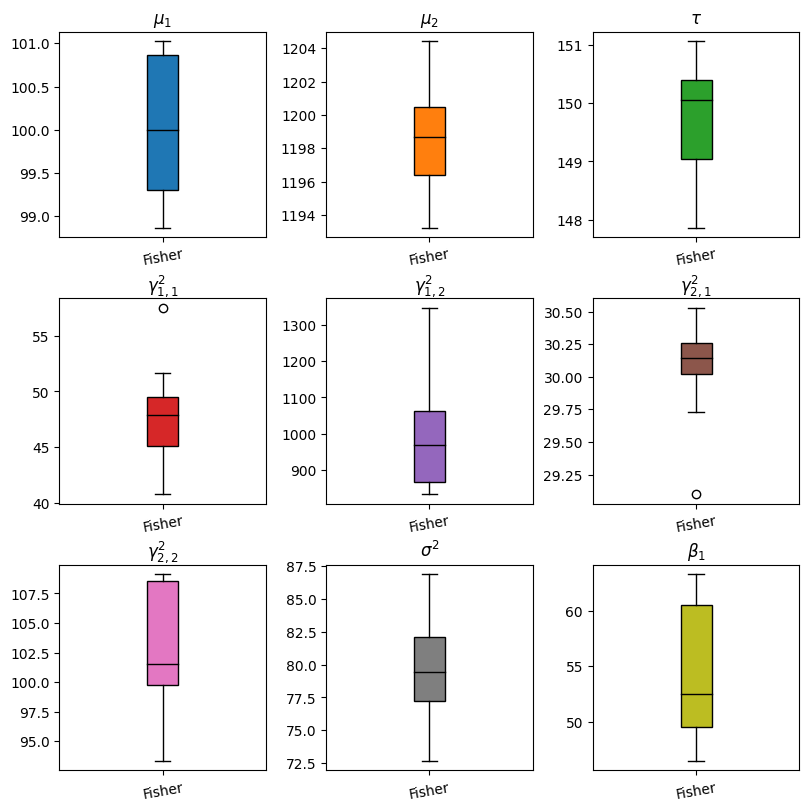

In [143]:
id_to_plot = jnp.array([1, 2, 3, 4, 7, 8, 9, 10, 11]) - 1
scenarios_labels = [x[7:] for x in results.get_scenarios_labels("name")]

params_names = (
    ["$\\mu_1$", "$\\mu_2$", "$\\tau$"]
    + [f"$\\gamma^2_{{{1+i//2},{1+i%2}}}$" for i in range(2 * 2)]
    + ["$\\sigma^2$"]
    + [f"$\\beta_{1+i}$" for i in range(myModel.P)]
)

x = results.last_theta[:, :, -1]

fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(3, 3)

for i in range(len(id_to_plot)):
    sdgplt.boxplot(
        x=x[:, :, id_to_plot[i]],
        xlabels=scenarios_labels,
        title=params_names[i],
        facecolor=f"C{i}",
        fig=subfigs[i // subfigs.shape[0]][i % subfigs.shape[1]],
    )
# fig.tight_l<ayout()
for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=10)

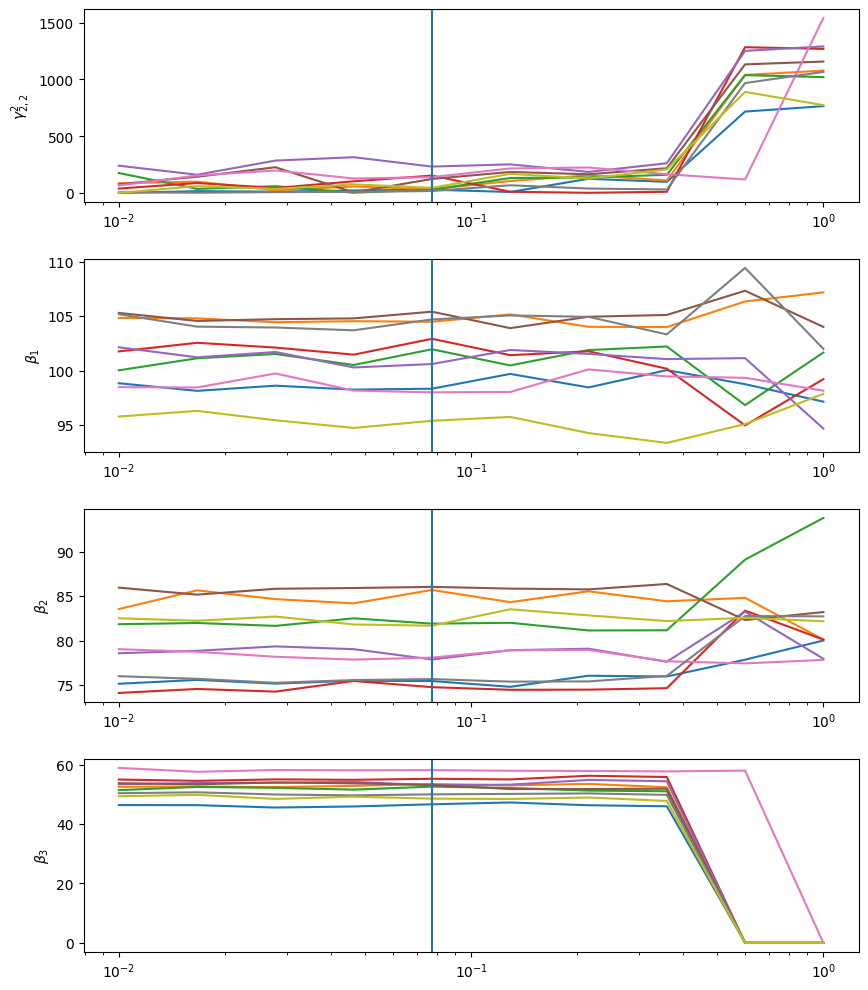

In [37]:
fig = sdgplt.figure(10, 10)
subfigs = fig.subfigures(4, 1)

id = [6, 8, 9, 10]
for i in range(4):
    subfigs[i].subplots(1, 1).plot(
        results[0][0].lbd_set,
        jnp.array([[r.last_theta[1, id[i]] for r in run] for run in results[0]]).T,
    )

    subfigs[i].axes[0].set_ylabel(params_names[id[i]])
    subfigs[i].axes[0].set_xscale("log")
    subfigs[i].axes[0].axvline(results[0][0].lbd_set[4])

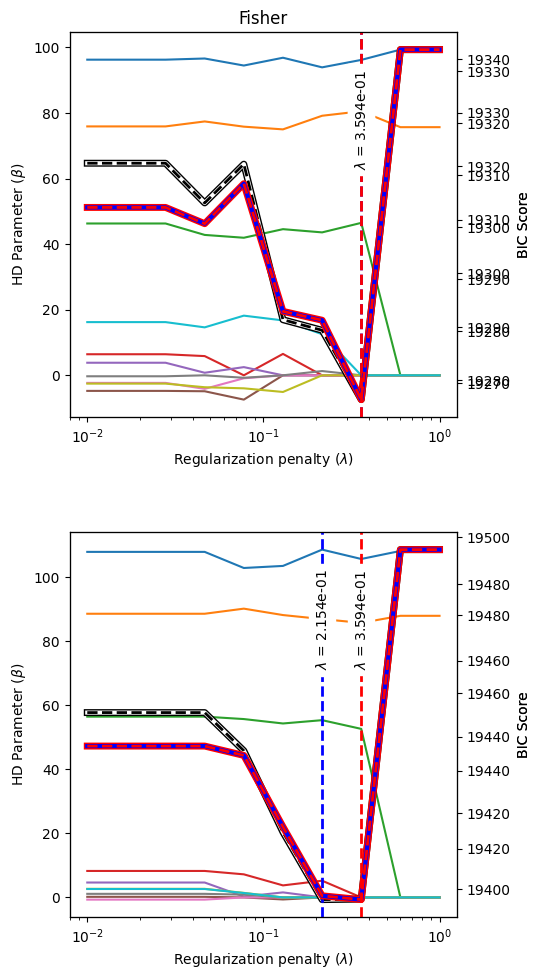

In [201]:
from sdg4varselect.plot import plot_reg_path, _plot_bic
import numpy as np

fig = sdgplt.figure(10, 5 * len(results))
subfigs = fig.subfigures(2, len(results))
if len(subfigs.shape) == 1:
    subfigs = np.array([subfigs]).T

for i in range(len(results)):
    for j in range(subfigs.shape[0]):
        reg = results[i][j].standardize()
        ax = plot_reg_path(
            reg_res=reg,
            dim_ld=7 + 1,
            fig=subfigs[j][i] if len(subfigs.shape) == 2 else subfigs[i],
        )

        _plot_bic(
            ax=ax.axes[0],
            lbd_set=reg.lbd_set,
            bic=reg.ebic[-1],
            argmin_bic=jnp.argmin(reg.ebic[-1]),
            colors=["r", "b", "r"],
            msg="eBIC",
        )

        subfigs[j][i].axes[0].set_title("")

    subfigs[0][i].axes[0].set_title(results.config[i]["name"])

In [158]:
import pandas as pd
from sdg4varselect.outputs import TestResults, MultiRunRes

m = LogisticMixedEffectsModel
config = [
    {"name": "Fisher", "seed_name": "100_80_50_S(1, 10)", "N": 200, "P": 500},
    {"name": "Fisher", "seed_name": "1000_S(1, 9)", "N": 200, "P": 10},
    {"name": "Fisher", "seed_name": "Snotf(1, 10)", "N": 200, "P": 500},
]

from sdg4varselect._regularization_function import eBIC

runres = []
for c in config:
    multires = MultiRunRes.load(
        m(N=c["N"], J=15, P=c["P"]),
        # "files",
        filename_add_on=f"{c['seed_name']}_{c['name']}",
    )
    runres.append(multires)

results = TestResults(runres, config)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])
scenarios_labels = [c["name"] for c in config]

LogisticMEM_N200_J15_P500_100_80_50_S(1, 10)_Fisher LOADED !
LogisticMEM_N200_J15_P10_1000_S(1, 9)_Fisher LOADED !
LogisticMEM_N200_J15_P500_Snotf(1, 10)_Fisher LOADED !
chrono = ['16:24:47.842154', '0:19:03.869494', '2 days, 14:53:44.317652']
[7, 7, 7]


Text(0.5, 1.0, 'N = 100, P = 500, beta = [80,50,30]')

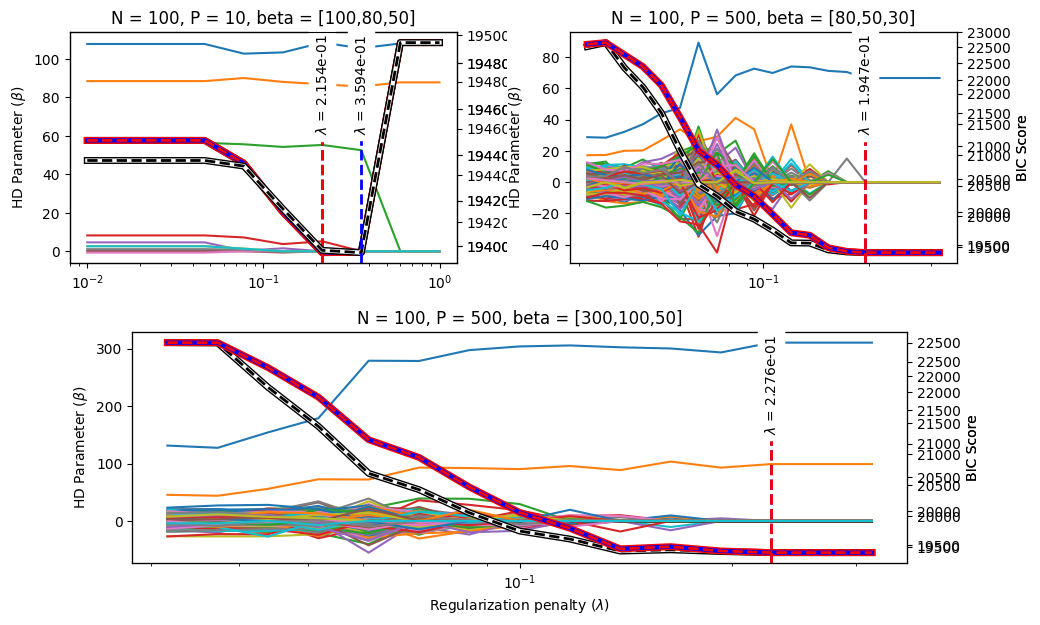

In [164]:
from sdg4varselect.plot import plot_reg_path, _plot_bic

fig = sdgplt.figure(6, 10)
subfigs1 = fig.subfigures(2, 1)
subfigs2 = subfigs1[0].subfigures(1, 2)
fig.tight_layout()
# ==
reg = results[0][0].standardize()
fig = plot_reg_path(
    reg_res=reg,
    dim_ld=7 + 1,
    fig=subfigs1[1],
)
_plot_bic(
    ax=fig.axes[0],
    lbd_set=reg.lbd_set,
    bic=reg.ebic[-1],
    argmin_bic=jnp.argmin(reg.ebic[-1]),
    colors=["r", "b", "r"],
    msg="eBIC",
)

subfigs1[1].axes[0].set_title("N = 100, P = 500, beta = [300,100,50]")


# ==
reg = results[1][1].standardize()
fig = plot_reg_path(
    reg_res=reg,
    dim_ld=7 + 1,
    fig=subfigs2[0],
)
_plot_bic(
    ax=fig.axes[0],
    lbd_set=reg.lbd_set,
    bic=reg.bic[-1],
    argmin_bic=jnp.argmin(reg.bic[-1]),
    colors=["r", "b", "r"],
    msg="BIC",
)
_plot_bic(
    ax=fig.axes[0],
    lbd_set=reg.lbd_set,
    bic=reg.ebic[-1],
    argmin_bic=jnp.argmin(reg.ebic[-1]),
    # colors=["r", "b", "r"],
    msg="eBIC",
)

subfigs2[0].axes[0].set_title("N = 100, P = 10, beta = [100,80,50]")

# ==

reg = results[2][0].standardize()
fig = plot_reg_path(
    reg_res=reg,
    dim_ld=7 + 2,
    fig=subfigs2[1],
)
_plot_bic(
    ax=fig.axes[0],
    lbd_set=reg.lbd_set,
    bic=reg.ebic[-1],
    argmin_bic=jnp.argmin(reg.ebic[-1]),
    colors=["r", "b", "r"],
    msg="eBIC",
)

subfigs2[1].axes[0].set_title("N = 100, P = 500, beta = [80,50,30]")

In [ ]:
_ = sdgplt.plot_2_panel_selected_theta_hd(
    results,
    myModel.hstack_params(p_star),
    scenarios_labels,
    dim_ld=myModel.DIM_LD,
    fig=sdgplt.figure(5, 20),
    theta_name="$\\beta$",
)